In [1]:
# Install the required Hugging Face libraries and evaluation metrics
!pip install -q transformers datasets evaluate scikit-learn accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Dataset
# We use the IMDB dataset directly from HuggingFace for ease of use in Colab.
print("Loading dataset...")
dataset = load_dataset("imdb")

# 2. Data Splitting & Preprocessing
# The IMDB dataset comes with train and test splits. We will create a validation split.
# To make training faster for this assignment, we will use a smaller subset (e.g., 2000 samples).
# If you want to train on the full dataset, remove the select() method, but it will take much longer!
train_data = dataset['train'].shuffle(seed=42).select(range(2000))
test_val_data = dataset['test'].shuffle(seed=42).select(range(1000))

# Split the test_val_data into validation (50%) and test (50%)
split_data = test_val_data.train_test_split(test_size=0.5)
val_data = split_data['train']
test_data = split_data['test']

print(f"Train size: {len(train_data)}, Validation size: {len(val_data)}, Test size: {len(test_data)}")

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size: 2000, Validation size: 500, Test size: 500


In [3]:
# Load the pre-trained BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    # Padding and truncation ensure all sequences have the same length (max 512 for BERT)
    return tokenizer(examples["text"], padding="max_length", truncation=True)

# Apply tokenization to all datasets
print("Tokenizing datasets...")
tokenized_train = train_data.map(tokenize_function, batched=True)
tokenized_val = val_data.map(tokenize_function, batched=True)
tokenized_test = test_data.map(tokenize_function, batched=True)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing datasets...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [4]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Calculate metrics using scikit-learn
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [6]:
print("--- Starting Experiment 1: Freezing BERT Layers ---")

# Load pre-trained BERT model for sequence classification
model_exp1 = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# Freeze all layers in the BERT model
for param in model_exp1.bert.parameters():
    param.requires_grad = False

# Define Training Arguments for Experiment 1
training_args_exp1 = TrainingArguments(
    output_dir="./results_exp1",
    eval_strategy="epoch",  # Changed from evaluation_strategy to eval_strategy
    learning_rate=2e-5,      # As required by the task [cite: 64]
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
)

# Initialize Trainer
trainer_exp1 = Trainer(
    model=model_exp1,
    args=training_args_exp1,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

# Train the model
trainer_exp1.train()

# Evaluate on Test Set
print("Evaluating Experiment 1 on Test Set:")
results_exp1 = trainer_exp1.evaluate(tokenized_test)
print(results_exp1)

--- Starting Experiment 1: Freezing BERT Layers ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.682979,0.578000,0.674884,0.544776,0.886640
2,No log,0.681466,0.582000,0.671900,0.548718,0.866397
3,No log,0.680619,0.588000,0.664495,0.555858,0.825911


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluating Experiment 1 on Test Set:


{'eval_loss': 0.6827827095985413, 'eval_accuracy': 0.578, 'eval_f1': 0.6728682170542636, 'eval_precision': 0.5371287128712872, 'eval_recall': 0.9004149377593361, 'eval_runtime': 16.0415, 'eval_samples_per_second': 31.169, 'eval_steps_per_second': 1.995, 'epoch': 3.0}


In [7]:
print("--- Starting Experiment 2: Fine-Tuning Last 2 Layers ---")

# Load a fresh pre-trained BERT model
model_exp2 = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# First, freeze all BERT layers
for param in model_exp2.bert.parameters():
    param.requires_grad = False

# Unfreeze the last 2 layers of the encoder (BERT has 12 layers: 0 to 11)
# We will unfreeze layer 10 and 11
for param in model_exp2.bert.encoder.layer[10].parameters():
    param.requires_grad = True
for param in model_exp2.bert.encoder.layer[11].parameters():
    param.requires_grad = True

training_args_exp2 = TrainingArguments(
    output_dir="./results_exp2",
    eval_strategy="epoch",  # Changed from evaluation_strategy to eval_strategy
    learning_rate=2e-5,      # As required by the task [cite: 64]
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
)

# Initialize Trainer
trainer_exp2 = Trainer(
    model=model_exp2,
    args=training_args_exp2,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

# Train the model
trainer_exp2.train()

# Evaluate on Test Set
print("Evaluating Experiment 2 on Test Set:")
results_exp2 = trainer_exp2.evaluate(tokenized_test)
print(results_exp2)

--- Starting Experiment 2: Fine-Tuning Last 2 Layers ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.436164,0.830000,0.836852,0.795620,0.882591
2,No log,0.404069,0.818000,0.837790,0.748408,0.951417


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.436164,0.830000,0.836852,0.795620,0.882591
2,No log,0.404069,0.818000,0.837790,0.748408,0.951417
3,No log,0.316844,0.866000,0.866799,0.851562,0.882591


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluating Experiment 2 on Test Set:


{'eval_loss': 0.2949824035167694, 'eval_accuracy': 0.89, 'eval_f1': 0.8919449901768173, 'eval_precision': 0.8470149253731343, 'eval_recall': 0.941908713692946, 'eval_runtime': 15.7565, 'eval_samples_per_second': 31.733, 'eval_steps_per_second': 2.031, 'epoch': 3.0}


Confusion Matrix for Experiment 1:


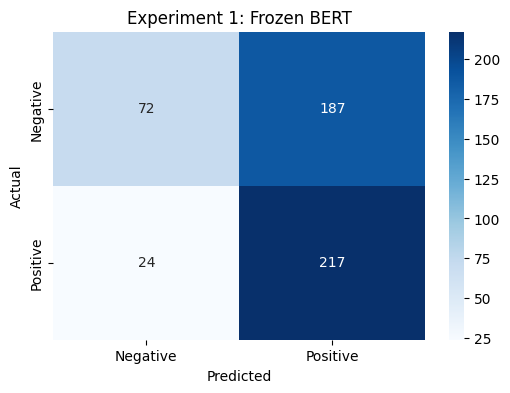

Confusion Matrix for Experiment 2:


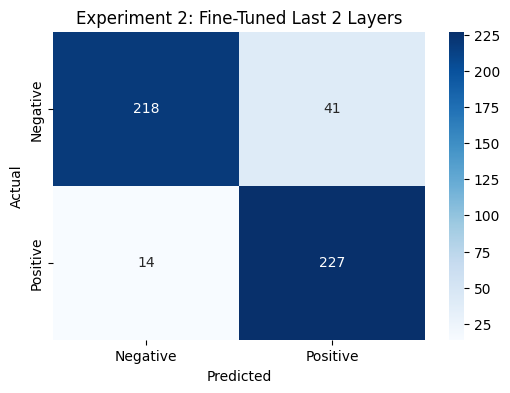


--- Performance Comparison ---
               Experiment  Accuracy  Precision   Recall       F1
           Exp 1 (Frozen)     0.578   0.537129 0.900415 0.672868
Exp 2 (Fine-Tuned Last 2)     0.890   0.847015 0.941909 0.891945


In [8]:
# Function to plot confusion matrix
def plot_confusion_matrix(trainer, dataset, title):
    predictions, labels, _ = trainer.predict(dataset)
    preds = np.argmax(predictions, axis=-1)

    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

print("Confusion Matrix for Experiment 1:")
plot_confusion_matrix(trainer_exp1, tokenized_test, "Experiment 1: Frozen BERT")

print("Confusion Matrix for Experiment 2:")
plot_confusion_matrix(trainer_exp2, tokenized_test, "Experiment 2: Fine-Tuned Last 2 Layers")

# Create a comparison table using pandas
print("\n--- Performance Comparison ---")
comparison_df = pd.DataFrame([
    {"Experiment": "Exp 1 (Frozen)",
     "Accuracy": results_exp1['eval_accuracy'],
     "Precision": results_exp1['eval_precision'],
     "Recall": results_exp1['eval_recall'],
     "F1": results_exp1['eval_f1']},

    {"Experiment": "Exp 2 (Fine-Tuned Last 2)",
     "Accuracy": results_exp2['eval_accuracy'],
     "Precision": results_exp2['eval_precision'],
     "Recall": results_exp2['eval_recall'],
     "F1": results_exp2['eval_f1']}
])

print(comparison_df.to_string(index=False))